<a href="https://colab.research.google.com/github/shruthilakshmi008-BA/ba-automation-suite/blob/main/06-Enterprise-O2C-Pipeline/06_Enterprise_O2C_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q --force-reinstall \
    pandas==2.2.3 \
    google-auth==2.49.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.7/240.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.3/181.3 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.5/347.5 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.8/221.8 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.4/84.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 3.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does no

In [3]:
!pip -q install -U google-genai pandas matplotlib

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.0 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.


In [4]:
import os
import re
import pandas as pd
from IPython.display import display

# Optional GenAI setup
try:
    import google.generativeai as genai
    GENAI_AVAILABLE = True
except ImportError:
    GENAI_AVAILABLE = False

# Configuration
HIGH_VALUE_THRESHOLD = 5000.00

STATUS_MAP = {
    'ok': 'APPROVED',
    'approved': 'APPROVED',
    'verified': 'APPROVED',
    'pending': 'PENDING_REVIEW',
    'review required': 'PENDING_REVIEW',
    'failed': 'REJECTED',
    'rejected': 'REJECTED'
}

print("Setup complete.")
print(f"High-value threshold: ${HIGH_VALUE_THRESHOLD:,.2f}")
print(f"Gemini library available: {GENAI_AVAILABLE}")

Setup complete.
High-value threshold: $5,000.00
Gemini library available: True


/usr/local/lib/python3.13/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [5]:
import os
from getpass import getpass

GEMINI_API_KEY = None

# Try Google Colab Secrets first
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
    print("Gemini API key loaded from Colab Secrets.")
except Exception:
    pass

# Manual fallback
if not GEMINI_API_KEY:
    GEMINI_API_KEY = getpass("Enter your Gemini API key: ")

if GEMINI_API_KEY:
    os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY
    print("Gemini API key configured.")
else:
    print("No Gemini API key provided. AI fallback will be disabled.")

Gemini API key loaded from Colab Secrets.
Gemini API key configured.


In [6]:
from google.colab import files

uploaded = files.upload()

input_file = next(iter(uploaded.keys()))

print(f"Uploaded file: {input_file}")

Saving ingestion_file.csv to ingestion_file.csv
Uploaded file: ingestion_file.csv


In [7]:
df_orders = pd.read_csv(input_file)

print("Input dataset shape:", df_orders.shape)

display(df_orders)

Input dataset shape: (5, 3)


,order_id,raw_status,raw_invoice_text
0,ORD-901,ok,Invoice #: INV-901 Vendor: Acme Industrial Tot...
1,ORD-902,pending,Invoice #: INV-902 Vendor: Global Tech Solutio...
2,ORD-903,approved,Invoice: INV-903 - Vendor Apex Logistics - Amo...
3,ORD-904,review required,Invoice #: INV-904 Vendor: Summit Office Total...
4,ORD-905,verified,Invoice #: INV-905 Vendor: Pinnacle Systems To...


In [8]:
required_columns = [
    'order_id',
    'raw_status',
    'raw_invoice_text'
]

missing_columns = [
    col for col in required_columns
    if col not in df_orders.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("All required columns are present.")

All required columns are present.


In [9]:
def normalize_status(raw_status: str) -> str:
    """
    Converts raw status values into:
    APPROVED
    PENDING_REVIEW
    REJECTED

    Uses Gemini only when the status is not found
    in the predefined dictionary.
    """

    if not isinstance(raw_status, str):
        return 'PENDING_REVIEW'

    clean_status = raw_status.strip().lower()

    # 1. Direct dictionary match
    if clean_status in STATUS_MAP:
        return STATUS_MAP[clean_status]

    # 2. Gemini fallback
    if GENAI_AVAILABLE and os.getenv("GEMINI_API_KEY"):

        try:
            genai.configure(
                api_key=os.getenv("GEMINI_API_KEY")
            )

            model = genai.GenerativeModel(
                "gemini-1.5-flash"
            )

            prompt = f"""
Classify this order status into exactly ONE of:

APPROVED
PENDING_REVIEW
REJECTED

Order status:
{raw_status}

Return ONLY the canonical status.
"""

            response = model.generate_content(prompt)

            ai_status = response.text.strip().upper()

            if ai_status in [
                'APPROVED',
                'PENDING_REVIEW',
                'REJECTED'
            ]:
                return ai_status

        except Exception as e:
            print(
                f"Gemini fallback failed for "
                f"'{raw_status}': {e}"
            )

    # 3. Safe default
    return 'PENDING_REVIEW'

In [10]:
def parse_invoice_text(invoice_text: str) -> dict:
    """
    Extracts:
    - invoice_number
    - vendor
    - total
    """

    metadata = {
        'invoice_number': 'NEEDS_REVIEW',
        'vendor': 'NEEDS_REVIEW',
        'total': 0.0
    }

    if not isinstance(invoice_text, str):
        return metadata

    # Invoice number
    inv_match = re.search(
        r'(?:Invoice\s*#?|Inv\s*#?)\s*:?\s*([A-Za-z0-9-]+)',
        invoice_text,
        re.IGNORECASE
    )

    if inv_match:
        metadata['invoice_number'] = (
            inv_match.group(1).strip()
        )

    # Vendor
    vendor_match = re.search(
        r'Vendor\s*:\s*([^\n\r,]+)',
        invoice_text,
        re.IGNORECASE
    )

    if vendor_match:
        metadata['vendor'] = (
            vendor_match.group(1).strip()
        )

    # Total
    total_match = re.search(
        r'Total\s*:\s*\$?\s*([0-9,]+(?:\.[0-9]+)?)',
        invoice_text,
        re.IGNORECASE
    )

    if total_match:
        try:
            clean_total = (
                total_match.group(1)
                .replace(',', '')
            )

            metadata['total'] = float(clean_total)

        except ValueError:
            metadata['total'] = 0.0

    return metadata

In [11]:
def process_o2c_orders(df_orders: pd.DataFrame) -> pd.DataFrame:

    processed_records = []

    for _, row in df_orders.iterrows():

        order_id = row.get(
            'order_id',
            'ORD-UNKNOWN'
        )

        raw_status = str(
            row.get('raw_status', '')
        )

        raw_invoice_text = str(
            row.get('raw_invoice_text', '')
        )

        # 1. Normalize status
        canonical_status = normalize_status(
            raw_status
        )

        # 2. Extract invoice metadata
        meta = parse_invoice_text(
            raw_invoice_text
        )

        # 3. Compliance evaluation
        total_val = meta['total']

        exception_reason = 'NONE'

        if total_val >= HIGH_VALUE_THRESHOLD:

            canonical_status = 'PENDING_REVIEW'

            exception_reason = (
                f'Exceeds ${HIGH_VALUE_THRESHOLD:,.2f} '
                'Approval Threshold'
            )

        elif canonical_status == 'PENDING_REVIEW':

            exception_reason = (
                'Unresolved Raw Status or '
                'Missing Attributes'
            )

        processed_records.append({
            'order_id': order_id,
            'raw_status': raw_status,
            'canonical_status': canonical_status,
            'invoice_number': meta['invoice_number'],
            'vendor': meta['vendor'],
            'total': total_val,
            'exception_reason': exception_reason
        })

    return pd.DataFrame(processed_records)

In [12]:
df_processed = process_o2c_orders(df_orders)

print("Processing complete.")
print("Processed dataset shape:", df_processed.shape)

display(df_processed)

Processing complete.
Processed dataset shape: (5, 7)


,order_id,raw_status,canonical_status,invoice_number,vendor,total,exception_reason
0,ORD-901,ok,APPROVED,INV-901,Acme Industrial Total: $1,1250.0,NONE
1,ORD-902,pending,PENDING_REVIEW,INV-902,Global Tech Solutions Total: $6,6400.0,"Exceeds $5,000.00 Approval Threshold"
2,ORD-903,approved,APPROVED,INV-903,NEEDS_REVIEW,0.0,NONE
3,ORD-904,review required,PENDING_REVIEW,INV-904,Summit Office Total: $8,8900.0,"Exceeds $5,000.00 Approval Threshold"
4,ORD-905,verified,APPROVED,INV-905,Pinnacle Systems Total: $3,3100.0,NONE


In [13]:
display(
    df_processed[
        [
            'order_id',
            'canonical_status',
            'invoice_number',
            'vendor',
            'total',
            'exception_reason'
        ]
    ]
)

df_exceptions = df_processed[
    df_processed['exception_reason'] != 'NONE'
]

print(
    f"Exception orders: {len(df_exceptions)}"
)

display(df_exceptions)

,order_id,canonical_status,invoice_number,vendor,total,exception_reason
0,ORD-901,APPROVED,INV-901,Acme Industrial Total: $1,1250.0,NONE
1,ORD-902,PENDING_REVIEW,INV-902,Global Tech Solutions Total: $6,6400.0,"Exceeds $5,000.00 Approval Threshold"
2,ORD-903,APPROVED,INV-903,NEEDS_REVIEW,0.0,NONE
3,ORD-904,PENDING_REVIEW,INV-904,Summit Office Total: $8,8900.0,"Exceeds $5,000.00 Approval Threshold"
4,ORD-905,APPROVED,INV-905,Pinnacle Systems Total: $3,3100.0,NONE


Exception orders: 2


,order_id,raw_status,canonical_status,invoice_number,vendor,total,exception_reason
1,ORD-902,pending,PENDING_REVIEW,INV-902,Global Tech Solutions Total: $6,6400.0,"Exceeds $5,000.00 Approval Threshold"
3,ORD-904,review required,PENDING_REVIEW,INV-904,Summit Office Total: $8,8900.0,"Exceeds $5,000.00 Approval Threshold"


In [14]:
output_file = "o2c_processed_orders.csv"

df_processed.to_csv(
    output_file,
    index=False
)

print(f"Output saved as: {output_file}")
from google.colab import files

files.download(output_file)

Output saved as: o2c_processed_orders.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
print("===== O2C PROCESSING SUMMARY =====")

print(f"Total orders: {len(df_processed)}")

print(
    f"Approved: "
    f"{(df_processed['canonical_status'] == 'APPROVED').sum()}"
)

print(
    f"Pending Review: "
    f"{(df_processed['canonical_status'] == 'PENDING_REVIEW').sum()}"
)

print(
    f"Rejected: "
    f"{(df_processed['canonical_status'] == 'REJECTED').sum()}"
)

print(
    f"Exceptions: "
    f"{len(df_exceptions)}"
)

print(
    f"Total invoice value: "
    f"${df_processed['total'].sum():,.2f}"
)

===== O2C PROCESSING SUMMARY =====
Total orders: 5
Approved: 3
Pending Review: 2
Rejected: 0
Exceptions: 2
Total invoice value: $19,650.00


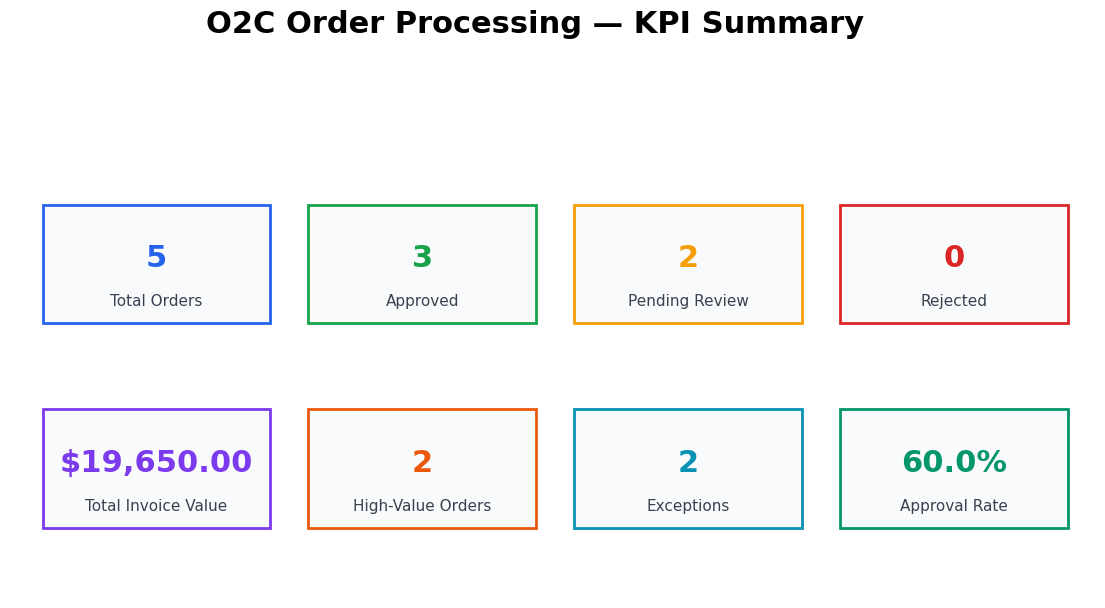

In [16]:
import matplotlib.pyplot as plt

# KPI calculations
total_orders = len(df_processed)

approved = (df_processed['canonical_status'] == 'APPROVED').sum()
pending = (df_processed['canonical_status'] == 'PENDING_REVIEW').sum()
rejected = (df_processed['canonical_status'] == 'REJECTED').sum()

total_value = df_processed['total'].sum()

high_value = (
    df_processed['total'] >= HIGH_VALUE_THRESHOLD
).sum()

exceptions = (
    df_processed['exception_reason'] != 'NONE'
).sum()

approval_rate = (
    approved / total_orders * 100
    if total_orders > 0 else 0
)

# Create KPI dashboard
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

fig.suptitle(
    'O2C Order Processing — KPI Summary',
    fontsize=22,
    fontweight='bold',
    y=0.95
)

kpis = [
    ('Total Orders', f'{total_orders:,}', '#2563EB'),
    ('Approved', f'{approved:,}', '#16A34A'),
    ('Pending Review', f'{pending:,}', '#F59E0B'),
    ('Rejected', f'{rejected:,}', '#DC2626'),
    ('Total Invoice Value', f'${total_value:,.2f}', '#7C3AED'),
    ('High-Value Orders', f'{high_value:,}', '#EA580C'),
    ('Exceptions', f'{exceptions:,}', '#0891B2'),
    ('Approval Rate', f'{approval_rate:.1f}%', '#059669')
]

for i, (label, value, color) in enumerate(kpis):
    row = i // 4
    col = i % 4

    x = 0.03 + col * 0.245
    y = 0.53 - row * 0.38

    ax.text(
        x + 0.105,
        y + 0.10,
        value,
        ha='center',
        va='center',
        fontsize=22,
        fontweight='bold',
        color=color,
        transform=ax.transAxes
    )

    ax.text(
        x + 0.105,
        y + 0.02,
        label,
        ha='center',
        va='center',
        fontsize=11,
        color='#374151',
        transform=ax.transAxes
    )

    # KPI card
    rect = plt.Rectangle(
        (x, y - 0.02),
        0.21,
        0.22,
        facecolor='#F9FAFB',
        edgecolor=color,
        linewidth=2,
        transform=ax.transAxes
    )

    ax.add_patch(rect)

# Save image
kpi_image = 'o2c_kpi_summary.png'

plt.savefig(
    kpi_image,
    dpi=200,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

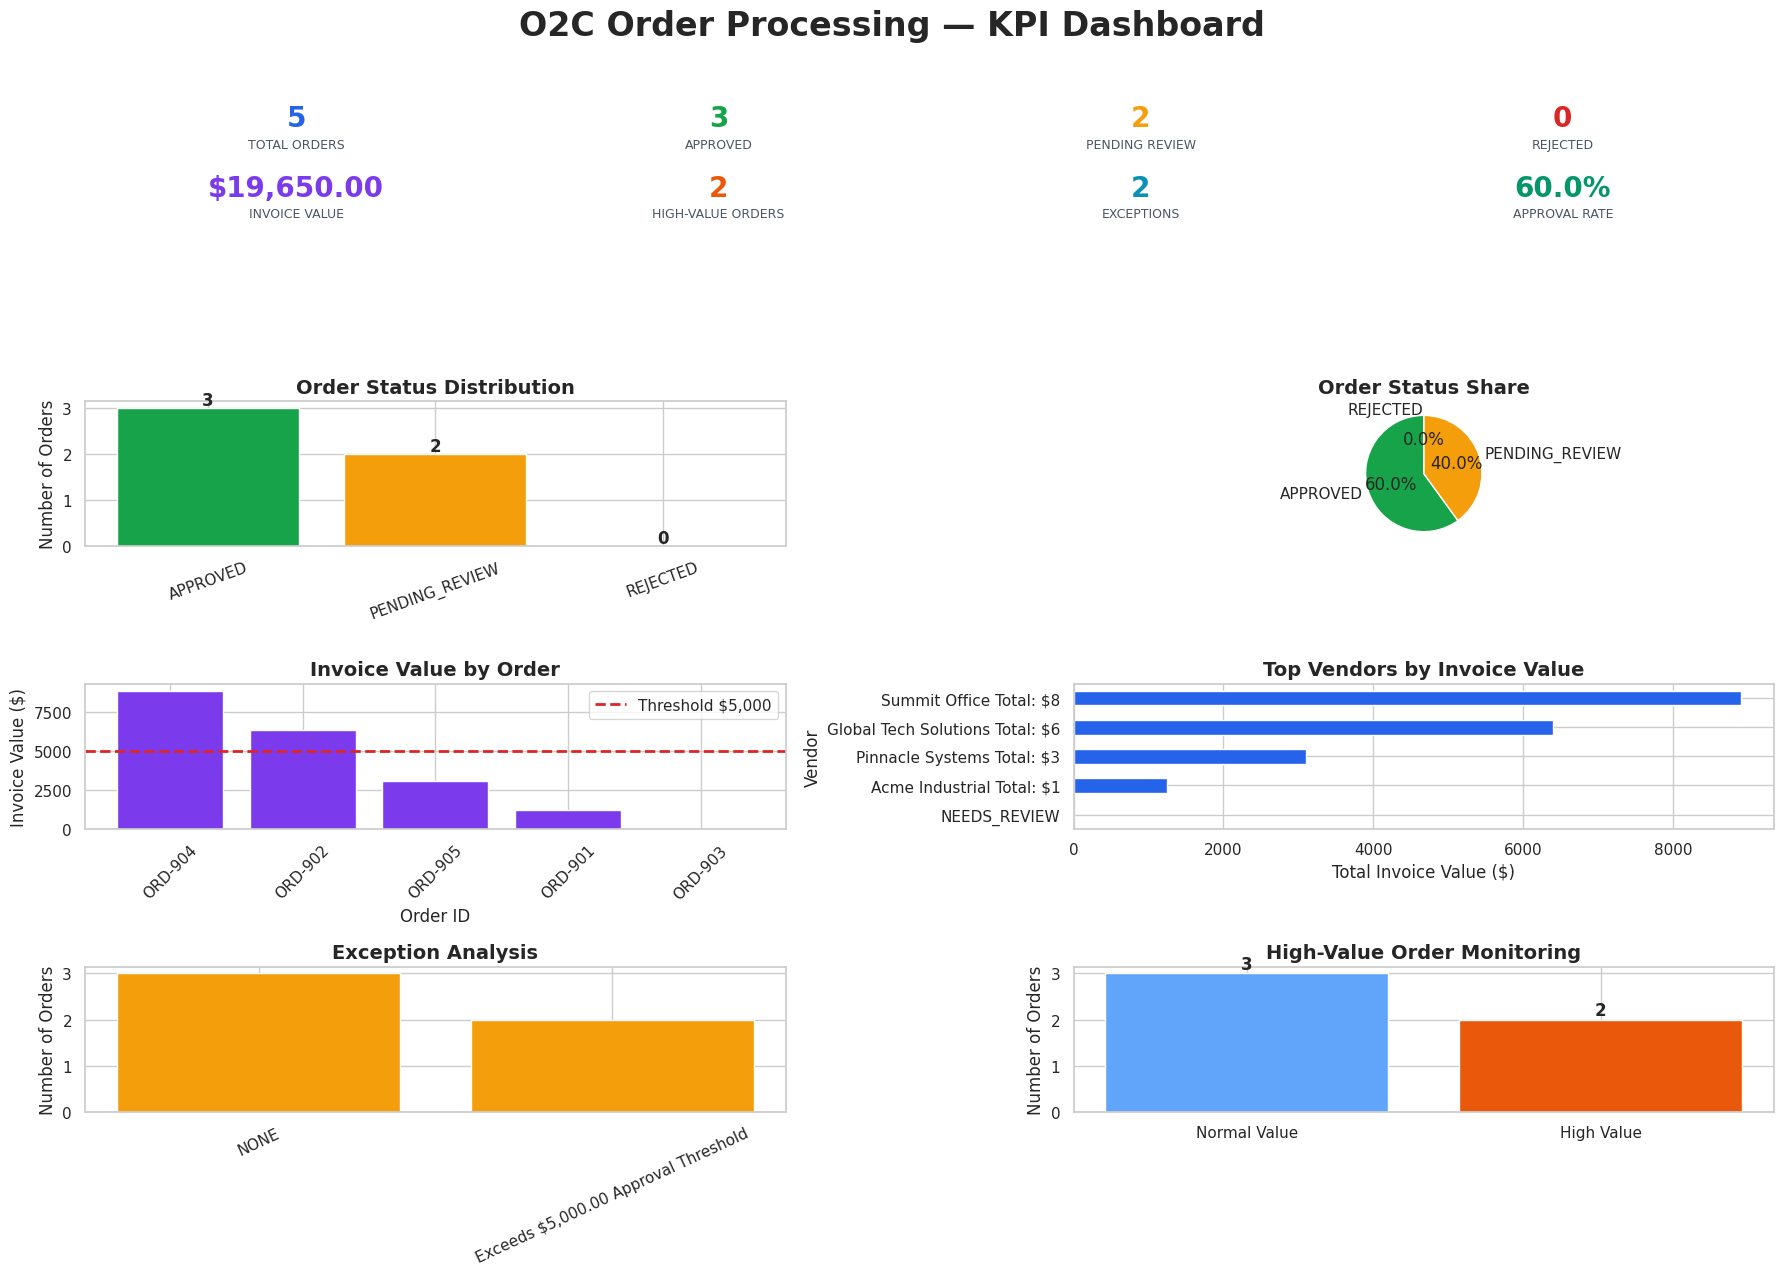

Dashboard saved as: o2c_kpi_dashboard.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# KPI calculations
# ---------------------------------------------------------
total_orders = len(df_processed)

status_counts = (
    df_processed['canonical_status']
    .value_counts()
    .reindex(
        ['APPROVED', 'PENDING_REVIEW', 'REJECTED'],
        fill_value=0
    )
)

total_value = df_processed['total'].sum()

high_value_orders = (
    df_processed['total'] >= HIGH_VALUE_THRESHOLD
).sum()

exception_counts = (
    df_processed['exception_reason']
    .value_counts()
)

vendor_value = (
    df_processed
    .groupby('vendor', dropna=False)['total']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# ---------------------------------------------------------
# Dashboard style
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")

fig = plt.figure(figsize=(18, 13))

fig.suptitle(
    "O2C Order Processing — KPI Dashboard",
    fontsize=24,
    fontweight="bold",
    y=0.98
)

# ---------------------------------------------------------
# 1. KPI CARDS
# ---------------------------------------------------------
ax_kpi = plt.subplot2grid(
    (4, 4), (0, 0), colspan=4
)

ax_kpi.axis("off")

approved = status_counts["APPROVED"]
pending = status_counts["PENDING_REVIEW"]
rejected = status_counts["REJECTED"]

approval_rate = (
    approved / total_orders * 100
    if total_orders else 0
)

kpis = [
    ("TOTAL ORDERS", f"{total_orders:,}", "#2563EB"),
    ("APPROVED", f"{approved:,}", "#16A34A"),
    ("PENDING REVIEW", f"{pending:,}", "#F59E0B"),
    ("REJECTED", f"{rejected:,}", "#DC2626"),
    ("INVOICE VALUE", f"${total_value:,.2f}", "#7C3AED"),
    ("HIGH-VALUE ORDERS", f"{high_value_orders:,}", "#EA580C"),
    ("EXCEPTIONS", f"{len(df_processed[df_processed['exception_reason'] != 'NONE']):,}", "#0891B2"),
    ("APPROVAL RATE", f"{approval_rate:.1f}%", "#059669")
]

for i, (label, value, color) in enumerate(kpis):

    x = i % 4
    y = 1 - (i // 4) * 0.48

    ax_kpi.text(
        x * 0.25 + 0.125,
        y,
        value,
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold",
        color=color,
        transform=ax_kpi.transAxes
    )

    ax_kpi.text(
        x * 0.25 + 0.125,
        y - 0.18,
        label,
        ha="center",
        va="center",
        fontsize=9,
        color="#4B5563",
        transform=ax_kpi.transAxes
    )

# ---------------------------------------------------------
# 2. ORDER STATUS DISTRIBUTION
# ---------------------------------------------------------
ax1 = plt.subplot2grid(
    (4, 4), (1, 0), colspan=2
)

colors = ["#16A34A", "#F59E0B", "#DC2626"]

ax1.bar(
    status_counts.index,
    status_counts.values,
    color=colors
)

ax1.set_title(
    "Order Status Distribution",
    fontsize=14,
    fontweight="bold"
)

ax1.set_ylabel("Number of Orders")
ax1.tick_params(axis="x", rotation=20)

for i, value in enumerate(status_counts.values):
    ax1.text(
        i,
        value + max(status_counts.values) * 0.02,
        str(value),
        ha="center",
        fontweight="bold"
    )

# ---------------------------------------------------------
# 3. STATUS PIE CHART
# ---------------------------------------------------------
ax2 = plt.subplot2grid(
    (4, 4), (1, 2), colspan=2
)

ax2.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white"}
)

ax2.set_title(
    "Order Status Share",
    fontsize=14,
    fontweight="bold"
)

# ---------------------------------------------------------
# 4. INVOICE VALUE BY ORDER
# ---------------------------------------------------------
ax3 = plt.subplot2grid(
    (4, 4), (2, 0), colspan=2
)

plot_df = df_processed.sort_values(
    "total",
    ascending=False
)

ax3.bar(
    plot_df["order_id"].astype(str),
    plot_df["total"],
    color="#7C3AED"
)

ax3.axhline(
    HIGH_VALUE_THRESHOLD,
    color="#DC2626",
    linestyle="--",
    linewidth=2,
    label=f"Threshold ${HIGH_VALUE_THRESHOLD:,.0f}"
)

ax3.set_title(
    "Invoice Value by Order",
    fontsize=14,
    fontweight="bold"
)

ax3.set_ylabel("Invoice Value ($)")
ax3.set_xlabel("Order ID")

ax3.tick_params(
    axis="x",
    rotation=45
)

ax3.legend()

# ---------------------------------------------------------
# 5. TOP VENDORS BY INVOICE VALUE
# ---------------------------------------------------------
ax4 = plt.subplot2grid(
    (4, 4), (2, 2), colspan=2
)

vendor_value.sort_values().plot(
    kind="barh",
    ax=ax4,
    color="#2563EB"
)

ax4.set_title(
    "Top Vendors by Invoice Value",
    fontsize=14,
    fontweight="bold"
)

ax4.set_xlabel("Total Invoice Value ($)")
ax4.set_ylabel("Vendor")

# ---------------------------------------------------------
# 6. EXCEPTION ANALYSIS
# ---------------------------------------------------------
ax5 = plt.subplot2grid(
    (4, 4), (3, 0), colspan=2
)

exception_plot = exception_counts.head(6)

ax5.bar(
    exception_plot.index.astype(str),
    exception_plot.values,
    color="#F59E0B"
)

ax5.set_title(
    "Exception Analysis",
    fontsize=14,
    fontweight="bold"
)

ax5.set_ylabel("Number of Orders")
ax5.tick_params(
    axis="x",
    rotation=25
)

# ---------------------------------------------------------
# 7. HIGH-VALUE VS NORMAL ORDERS
# ---------------------------------------------------------
ax6 = plt.subplot2grid(
    (4, 4), (3, 2), colspan=2
)

value_categories = [
    "Normal Value",
    "High Value"
]

normal_value = total_orders - high_value_orders

ax6.bar(
    value_categories,
    [normal_value, high_value_orders],
    color=["#60A5FA", "#EA580C"]
)

ax6.set_title(
    "High-Value Order Monitoring",
    fontsize=14,
    fontweight="bold"
)

ax6.set_ylabel("Number of Orders")

for i, value in enumerate(
    [normal_value, high_value_orders]
):
    ax6.text(
        i,
        value + max(total_orders, 1) * 0.02,
        str(value),
        ha="center",
        fontweight="bold"
    )

# ---------------------------------------------------------
# Final formatting
# ---------------------------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save high-resolution image
output_image = "o2c_kpi_dashboard.png"

plt.savefig(
    output_image,
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Dashboard saved as: {output_image}")
from google.colab import files

files.download("o2c_kpi_dashboard.png")
